# Import Library

In [1]:
# for cleaning the dataset
import pandas as pd
import numpy as np

# for modeling
import seaborn as sns
import matplotlib.pyplot as plt

# Cleaning the Dataset

In [2]:
#uploading dataset to file
csv_file_path = '/Users/kaitlynmcveigh/Documents/GitHub/DS480-Capstone/Weather2.csv'

weather = pd.read_csv(csv_file_path)
weather

,dt,dt_iso,timezone,city_name,lat,lon,temp,visibility,dew_point,feels_like,...,wind_gust,rain_1h,rain_3h,snow_1h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,1072915200,2004-01-01 00:00:00 +0000 UTC,-18000,New York,40.712775,-74.005973,278.05,NaN,271.79,274.34,...,NaN,NaN,NaN,NaN,NaN,0,800,Clear,sky is clear,01n
1,1072918800,2004-01-01 01:00:00 +0000 UTC,-18000,New York,40.712775,-74.005973,278.09,NaN,271.82,274.19,...,NaN,NaN,NaN,NaN,NaN,0,800,Clear,sky is clear,01n
2,1072922400,2004-01-01 02:00:00 +0000 UTC,-18000,New York,40.712775,-74.005973,278.32,10000.0,270.81,274.39,...,10.30,NaN,NaN,NaN,NaN,0,800,Clear,sky is clear,01n
3,1072926000,2004-01-01 03:00:00 +0000 UTC,-18000,New York,40.712775,-74.005973,277.48,NaN,271.68,273.34,...,NaN,NaN,NaN,NaN,NaN,2,800,Clear,sky is clear,01n
4,1072929600,2004-01-01 04:00:00 +0000 UTC,-18000,New York,40.712775,-74.005973,277.78,10000.0,270.36,274.50,...,NaN,NaN,NaN,NaN,NaN,0,800,Clear,sky is clear,01n
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195188,1735671600,2024-12-31 19:00:00 +0000 UTC,-18000,New York,40.712775,-74.005973,283.96,10000.0,277.21,282.74,...,NaN,NaN,NaN,NaN,NaN,0,800,Clear,sky is clear,01d
195189,1735675200,2024-12-31 20:00:00 +0000 UTC,-18000,New York,40.712775,-74.005973,283.77,10000.0,277.90,282.64,...,5.36,NaN,NaN,NaN,NaN,0,800,Clear,sky is clear,01d
195190,1735678800,2024-12-31 21:00:00 +0000 UTC,-18000,New York,40.712775,-74.005973,283.26,10000.0,278.84,282.26,...,NaN,NaN,NaN,NaN,NaN,0,800,Clear,sky is clear,01d
195191,1735682400,2024-12-31 22:00:00 +0000 UTC,-18000,New York,40.712775,-74.005973,282.80,10000.0,278.59,280.45,...,NaN,NaN,NaN,NaN,NaN,0,800,Clear,sky is clear,01n


In [3]:
#Converting dt_iso into DateTime Index
weather['dt_iso'] = weather['dt_iso'].str.replace(' UTC', '', regex=False)
weather['dt_iso'] = pd.to_datetime(weather['dt_iso'])

#setting dt_iso as index
weather = weather.set_index('dt_iso')

In [4]:
#Grouping only the numerical columns in the dataset to aggregate it from hourly to daily observations
weather = weather.groupby('dt_iso').mean(numeric_only=True)
weather = weather.resample('D').mean()

In [6]:
weather

,dt,timezone,lat,lon,temp,visibility,dew_point,feels_like,temp_min,temp_max,...,humidity,wind_speed,wind_deg,wind_gust,rain_1h,rain_3h,snow_1h,snow_3h,clouds_all,weather_id
dt_iso,,,,,,,,,,,,,,,,,,,,,
2004-01-01 00:00:00+00:00,1.072957e+09,-18000.0,40.712775,-74.005973,277.872083,10000.000000,270.344167,274.997917,277.445833,278.472083,...,57.125000,3.705417,215.333333,8.725000,NaN,NaN,NaN,NaN,12.166667,800.458333
2004-01-02 00:00:00+00:00,1.073043e+09,-18000.0,40.712775,-74.005973,277.277917,10000.000000,274.241667,276.286250,276.761250,277.873333,...,80.583333,1.476667,175.916667,NaN,0.155000,NaN,NaN,NaN,83.666667,778.166667
2004-01-03 00:00:00+00:00,1.073129e+09,-18000.0,40.712775,-74.005973,280.114583,10000.000000,278.744167,278.817500,279.476667,280.667917,...,91.041667,2.000417,152.500000,NaN,0.300000,NaN,NaN,NaN,84.541667,778.125000
2004-01-04 00:00:00+00:00,1.073216e+09,-18000.0,40.712775,-74.005973,282.029583,7520.000000,281.133750,280.698333,281.195833,282.696250,...,94.208333,2.612083,168.958333,7.700000,0.540000,0.65,NaN,NaN,96.250000,717.208333
2004-01-05 00:00:00+00:00,1.073302e+09,-18000.0,40.712775,-74.005973,276.806250,8116.666667,276.782083,273.485417,276.261667,277.535833,...,99.833333,3.991667,39.583333,8.620000,0.846000,2.05,NaN,NaN,100.000000,598.777778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27 00:00:00+00:00,1.735299e+09,-18000.0,40.712775,-74.005973,273.947500,10000.000000,269.171667,271.001667,273.003750,275.032500,...,68.416667,2.674583,141.083333,4.099048,NaN,NaN,NaN,NaN,3.500000,800.125000
2024-12-28 00:00:00+00:00,1.735385e+09,-18000.0,40.712775,-74.005973,279.104583,6152.045455,277.405417,277.795833,278.031667,279.891250,...,89.000000,1.883333,156.458333,2.583333,0.658000,1.65,NaN,NaN,89.583333,639.395833
2024-12-29 00:00:00+00:00,1.735472e+09,-18000.0,40.712775,-74.005973,282.899167,NaN,281.847500,282.389167,282.424167,283.680417,...,93.333333,1.975833,161.666667,1.624545,0.536923,NaN,NaN,NaN,98.541667,639.416667


In [5]:
# Converting the values from C to F
weather['temp'] = ((weather['temp'] - 273.15) * 1.8) + 32

#Converts temp_max and temp_min to Fahrenheit
weather['temp_max'] = ((weather['temp_max'] - 273.15) * 1.8) + 32

weather['temp_min'] = ((weather['temp_min'] - 273.15) * 1.8) + 32

#Converts dew_point, and feels_like to Fahrenheit
weather['dew_point'] = ((weather['dew_point'] - 273.15) * 1.8) + 32

weather['feels_like'] = ((weather['feels_like'] - 273.15) * 1.8) + 32

#renames columns to reflect fahrenheit conversion
weather = weather.rename(columns={'temp': 'temp (F)',
                                  'dew_point': 'dew_point (F)',
                                  'feels_like': 'feels_like (F)',
                                  'temp_max': 'temp_max (F)',
                                  'temp_min': 'temp_min (F)'})

#make columns into whole numbers
weather['temp (F)'] = weather['temp (F)'].round(decimals=0)
weather['dew_point (F)'] = weather['dew_point (F)'].round(decimals=0)
weather['feels_like (F)'] = weather['feels_like (F)'].round(decimals=0)
weather['temp_max (F)'] = weather['temp_max (F)'].round(decimals=0)
weather['temp_min (F)'] = weather['temp_min (F)'].round(decimals=0)

In [6]:
#converting meters/sec into miles/hour (Imperial units)
weather['wind_speed'] = weather['wind_speed'] * 2.237
weather['wind_gust'] = weather['wind_gust'] * 2.237

#rename columns to reflect conversion
weather = weather.rename(columns={'wind_speed': 'wind_speed (mph)', 
                                  'wind_gust': 'wind_gust (mph)'})

weather['wind_gust (mph)'] = weather['wind_gust (mph)'].round(decimals=0)
weather['wind_speed (mph)'] = weather['wind_speed (mph)'].round(decimals=0)

In [7]:
#Convert mm to inches
weather['rain_1h'] = weather['rain_1h'] / 25.4
weather['rain_3h'] = weather['rain_3h'] / 25.4
weather['snow_1h'] = weather['snow_1h'] / 25.4
weather['snow_3h'] = weather['snow_3h'] / 25.4

#rename columns to reflect conversion
weather = weather.rename(columns={'rain_1h': 'rain_1h (in)',
                                  'rain_3h': 'rain_3h (in)',
                                  'snow_1h': 'snow_1h (in)',
                                  'snow_3h': 'snow_3h (in)'})

In [8]:
# converting NaN values to 0 for rain and snow
weather['rain_1h (in)'] = weather['rain_1h (in)'].fillna(0)
weather['rain_3h (in)'] = weather['rain_3h (in)'].fillna(0)
weather['snow_1h (in)'] = weather['snow_1h (in)'].fillna(0)
weather['snow_3h (in)'] = weather['snow_3h (in)'].fillna(0)

In [9]:
#Convert km to statute miles (SM)
weather['visibility'] = weather['visibility'] / 1.609

weather = weather.rename(columns={'visibility': 'visibility (SM)'})

In [10]:
# converting NaN values to 0 for rain and snow
weather['visibility (SM)'] = weather['visibility (SM)'].fillna(0)
weather['wind_gust (mph)'] = weather['wind_gust (mph)'].fillna(0)

In [11]:
#Cleaning the remainder of the dataset

In [12]:
#seeing if there are any values in this column
unique_values = weather['sea_level'].unique()
print(unique_values)

unique_values = weather['grnd_level'].unique()
print(unique_values)

[nan]
[nan]


In [13]:
#removing columns that are not needed
weather = weather.drop(['lat', 'lon', 'dt', 'timezone', 'sea_level', 'grnd_level','weather_id'], axis = 1)

#removed lat, long, city_name, and timezone because they are all the same for each observation since this is data for the same city
#removed dt because it was not useful to the dataset
#removed sea_level and grnd_level because there were no values in the columns, all NaN

In [14]:
#adding units to column heads

weather = weather.rename(columns={'pressure': 'pressure (hPa)', 
                                  'humidity': 'humidity (%)',
                                  'clouds_all': 'cloudiness (%)',})

In [15]:
#updated column descriptions
column_descriptions = {
    'dt_iso': 'Date and time',
    'temp (F)': 'Temperature in Fahrenheit',
    'visibility (SM)': 'Average visibility, Units: statute miles (SM). The maximum value of the visibility is 6.2 SM',
    'dew_point (F)': 'Atmospheric temperature (varying according to pressure and humidity) below which water droplets begin to condense and dew can form',
    'feels_like (F)': 'Temperature parameter that accounts for the human perception of weather',
    'temp_min (F)': 'Minimum temperature at the moment. (use these parameter optionally).',
    'temp_max (F)': 'Same as temp_min',
    'pressure (hPa)': 'Atmospheric pressure (on the sea level), Units: hPa',
    'humidity (%)': 'Humidity percentage',
    'wind_speed (mph)': 'Units: miles/hour',
    'wind_deg': 'Wind direction, Units: degrees',
    'wind_gust (mph)': 'Units: miles/hour',
    'rain_1h (in)': 'Rain volume for the last hour, Units: inches',
    'rain_3h (in)': 'Rain volume for the last 3 hours, Units: inches',
    'snow_1h (in)': 'same as rain but measured in liquid state.',
    'snow_3h (in)': 'same as rain but measured in liquid state.',
    'cloudiness (%)': 'cloudiness percentage',
    }

In [16]:
weather

,temp (F),visibility (SM),dew_point (F),feels_like (F),temp_min (F),temp_max (F),pressure (hPa),humidity (%),wind_speed (mph),wind_deg,wind_gust (mph),rain_1h (in),rain_3h (in),snow_1h (in),snow_3h (in),cloudiness (%)
dt_iso,,,,,,,,,,,,,,,,
2004-01-01 00:00:00+00:00,40.0,6215.040398,27.0,35.0,40.0,42.0,1023.541667,57.125000,8.0,215.333333,20.0,0.000000,0.000000,0.0,0.0,12.166667
2004-01-02 00:00:00+00:00,39.0,6215.040398,34.0,38.0,39.0,41.0,1023.666667,80.583333,3.0,175.916667,0.0,0.006102,0.000000,0.0,0.0,83.666667
2004-01-03 00:00:00+00:00,45.0,6215.040398,42.0,42.0,43.0,46.0,1016.958333,91.041667,4.0,152.500000,0.0,0.011811,0.000000,0.0,0.0,84.541667
2004-01-04 00:00:00+00:00,48.0,4673.710379,46.0,46.0,46.0,49.0,1013.333333,94.208333,6.0,168.958333,17.0,0.021260,0.025591,0.0,0.0,96.250000
2004-01-05 00:00:00+00:00,39.0,5044.541123,39.0,33.0,38.0,40.0,1012.666667,99.833333,9.0,39.583333,19.0,0.033307,0.080709,0.0,0.0,100.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27 00:00:00+00:00,33.0,6215.040398,25.0,28.0,32.0,35.0,1031.333333,68.416667,6.0,141.083333,9.0,0.000000,0.000000,0.0,0.0,3.500000
2024-12-28 00:00:00+00:00,43.0,3823.521103,40.0,40.0,41.0,44.0,1026.208333,89.000000,4.0,156.458333,6.0,0.025906,0.064961,0.0,0.0,89.583333
2024-12-29 00:00:00+00:00,50.0,0.000000,48.0,49.0,49.0,51.0,1020.375000,93.333333,4.0,161.666667,4.0,0.021139,0.000000,0.0,0.0,98.541667


# Visualizations

In [17]:
#Start off with visualizations that expand our knowledge of the dataset and its variables
#heat plots, correlation maps, etc. 

                  temp (F)  visibility (SM)  dew_point (F)  feels_like (F)  \
temp (F)          1.000000         0.079372       0.942853        0.997351   
visibility (SM)   0.079372         1.000000      -0.072292        0.066019   
dew_point (F)     0.942853        -0.072292       1.000000        0.948968   
feels_like (F)    0.997351         0.066019       0.948968        1.000000   
pressure (hPa)   -0.218298         0.167905      -0.272889       -0.209797   
humidity (%)      0.238368        -0.459922       0.542813        0.262240   
wind_speed (mph) -0.306156         0.031345      -0.289162       -0.340165   
wind_gust (mph)  -0.201877         0.003819      -0.207006       -0.209841   
rain_1h (in)      0.131248        -0.219287       0.217636        0.137246   
rain_3h (in)      0.044829        -0.205818       0.118789        0.049418   
snow_1h (in)     -0.178539        -0.178578      -0.143554       -0.179835   
snow_3h (in)     -0.128404        -0.176818      -0.099358      

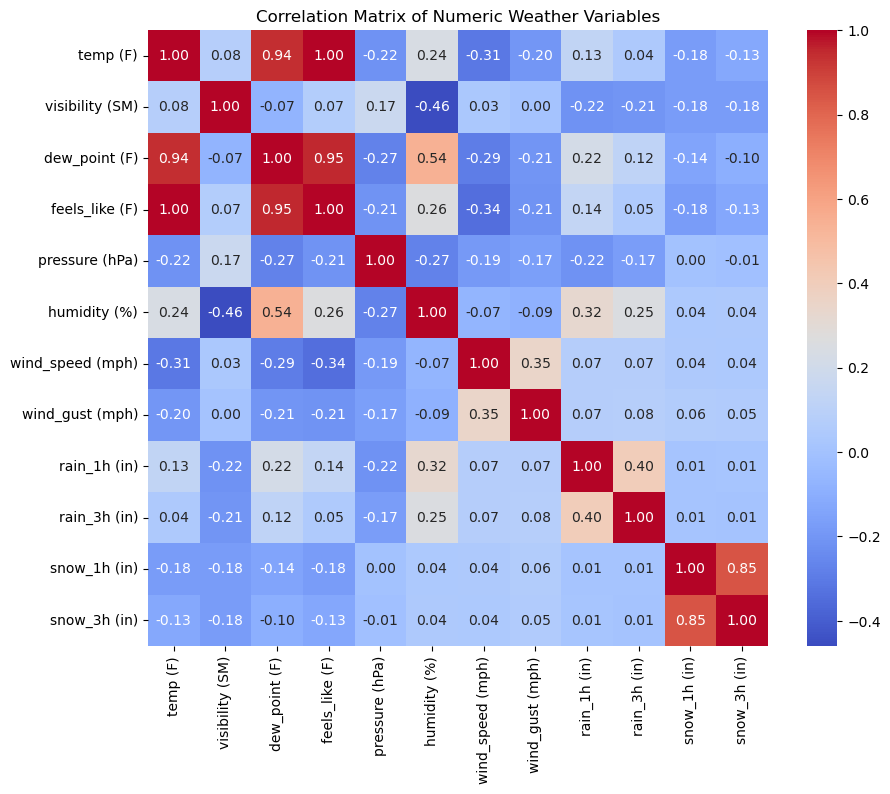

In [17]:
#heatplot between the variables
numeric_cols = ['temp (F)','visibility (SM)','dew_point (F)','feels_like (F)','pressure (hPa)','humidity (%)','wind_speed (mph)','wind_gust (mph)',
                'rain_1h (in)','rain_3h (in)','snow_1h (in)','snow_3h (in)']

weather_numeric = weather[numeric_cols]

corr_matrix = weather_numeric.corr()
print(corr_matrix)

plt.figure(figsize = (10,8))
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', fmt = ".2f")
plt.title('Correlation Matrix of Numeric Weather Variables')
plt.show()

### Forward Selection

In [20]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

In [21]:
#split into test and train
train_size = int(len(weather) * 0.5)
train = weather[:train_size]
test = weather[train_size:]

X_train = train.drop(columns = ['temp (F)'])
y_train = train['temp (F)']
X_test = test.drop(columns = ['temp (F)'])
y_test = test['temp (F)']

# model
model = LogisticRegression(max_iter = 1000)

#forward selection
sfs = SequentialFeatureSelector(model,
                          n_features_to_select = 4,
                          direction = 'forward')
sfs.fit(X_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org

KeyboardInterrupt: 

In [33]:
#cross correlation function (CCF)
from scipy.stats import pearsonr


scipy_correlation, _ = pearsonr(x, y)
print('SciPy Correlation:', scipy_correlation)

ValueError: `x` and `y` must be broadcastable.

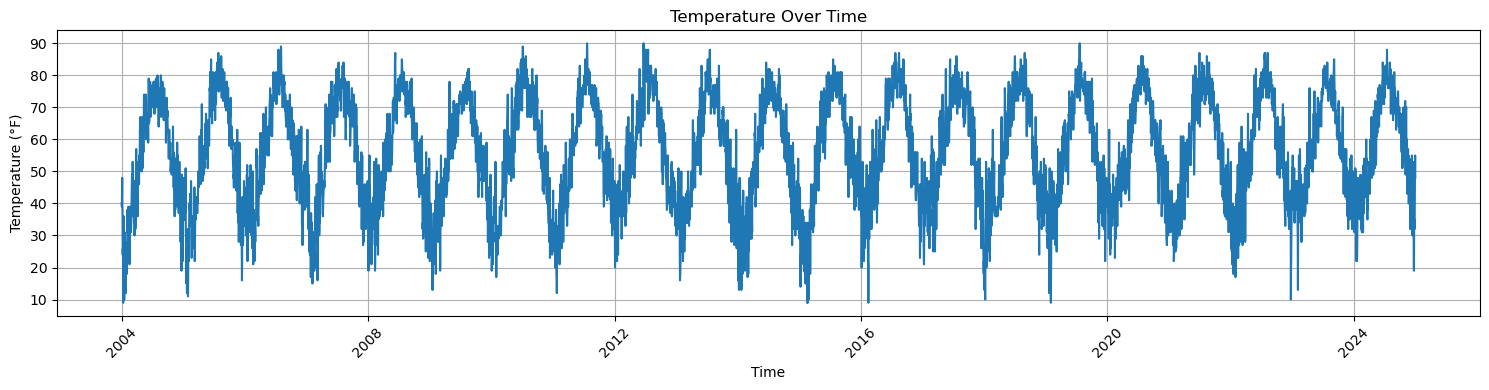

In [22]:
#Time series plot for temperature
plt.figure(figsize=(15, 4))

sns.lineplot(weather['temp (F)'])
plt.xlabel("Time")
plt.ylabel("Temperature (°F)")
plt.title("Temperature Over Time")

plt.xticks(rotation = 45)
plt.grid(True)

plt.tight_layout()
plt.show()

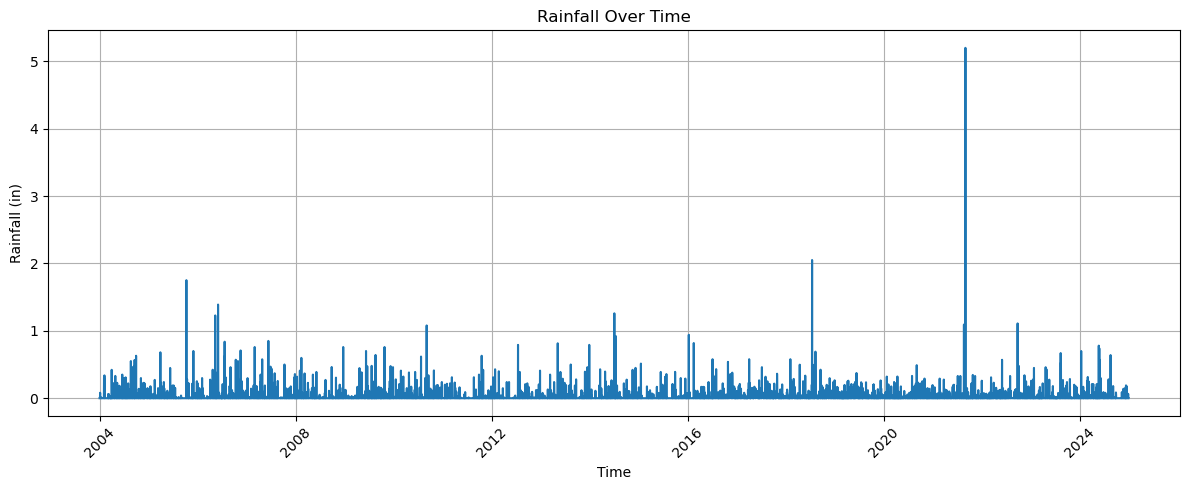

In [23]:
#Time series plot for rainfall
plt.figure(figsize=(12, 5))

sns.lineplot(weather['rain_3h (in)'])
plt.xlabel("Time")
plt.ylabel("Rainfall (in)")
plt.title("Rainfall Over Time")

plt.xticks(rotation = 45)
plt.grid(True)

plt.tight_layout()
plt.show()

# Lasso Regression

### Temperature

In [24]:
# packages
from sklearn.linear_model import Lasso, LassoCV
from sklearn.preprocessing import StandardScaler

#Accuracy Tester
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

In [ ]:
# can probably take out
y = weather['temp (F)']
x = weather.drop(columns = ['temp (F)'], axis = 1)

In [ ]:
train_size = int(len(weather) * 0.5)
train = weather[:train_size]
test = weather[train_size:]

X_train = scaler.fit_transform(train.drop(columns=['temp (F)']))
y_train = train['temp (F)']
X_test = scaler.transform(test.drop(columns=['temp (F)']))
y_test = test['temp (F)']

lasso_cv = LassoCV(alphas = None, cv = 10, max_iter = 10000)
lasso_cv.fit(X_train, y_train)

In [26]:
y_pred = lasso_cv.predict(X_test)

#R-squared
r2 = r2_score(y_test, y_pred)
print(f"R^2 Score: {r2}")

#root mean square error (measure of accuracy)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'RMSE: {rmse:.2f}')

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae}")

print(f"Optimal Alpha: {lasso_cv.alpha_}")

R^2 Score: 0.9990942347564812
RMSE: 0.50
MAE: 0.3900295302617737
Optimal Alpha: 0.017147742973613794


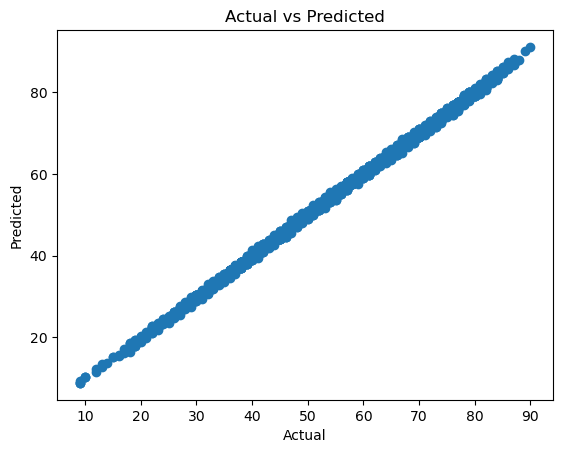

In [27]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

### Rainfall

In [29]:
y = weather['rain_3h (in)']
x = weather.drop(columns = ['rain_3h (in)'], axis = 1)

train_size = int(len(weather) * 0.5)
train = weather[:train_size]
test = weather[train_size:]

X_train = scaler.fit_transform(train.drop(columns=['rain_3h (in)']))
y_train = train['rain_3h (in)']
X_test = scaler.transform(test.drop(columns=['rain_3h (in)']))
y_test = test['rain_3h (in)']

lasso_cv = LassoCV(alphas=None, cv=10, max_iter=10000)
lasso_cv.fit(X_train, y_train)

LassoCV(cv=10, max_iter=10000)

In [30]:
y_pred = lasso_cv.predict(X_test)

#root mean square error (measure of accuracy)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'RMSE: {rmse:.2f}')

#R-squared
r2 = r2_score(y_test, y_pred)
print(f"R^2 Score: {r2}")

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae}")

print(f"Optimal Alpha: {lasso_cv.alpha_}")

RMSE: 0.12
R^2 Score: 0.07806404911727083
MAE: 0.03233071733019281
Optimal Alpha: 5.0575927157919886e-05


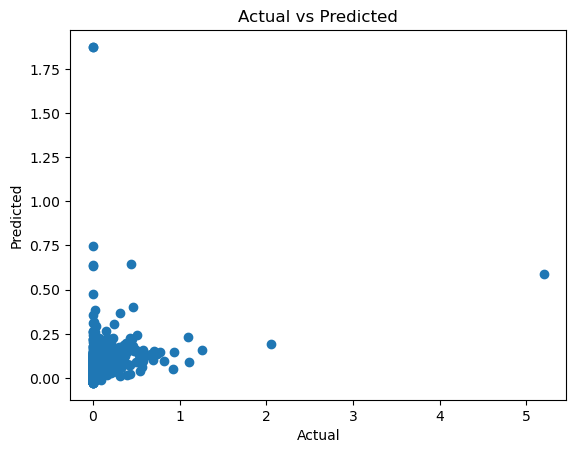

In [258]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

# ARIMAX

### Temperature

In [259]:
#packages
from statsmodels.tsa.stattools import adfuller #ADF test
from statsmodels.graphics.tsaplots import plot_acf #acf plot
from statsmodels.graphics.tsaplots import plot_pacf #pacf plot

from statsmodels.tsa.arima.model import ARIMA

In [260]:
#adf test
result = adfuller(weather['temp (F)'],
                 maxlag = None,
                 regression = 'ct',
                 autolag = 'AIC',
                 store = False,
                 regresults = True)


print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
# current p-value is higher than 0.05 so data is non-stationary (means differencing is needed)

ADF Statistic: -6.269639193337878
p-value: 5.855479440544349e-07


In [261]:
#differencing the data
y = weather['temp (F)'].diff().dropna()

<Figure size 640x480 with 0 Axes>

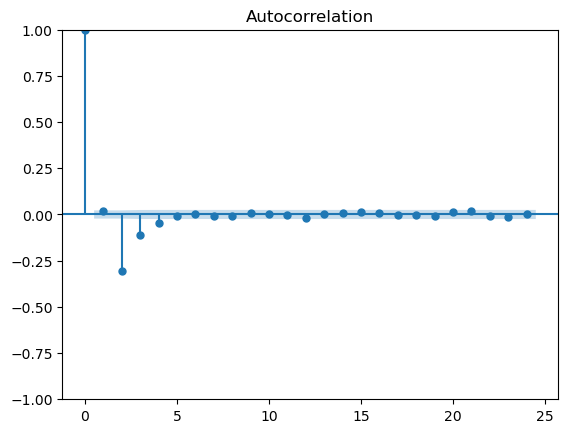

In [262]:
#acf plot for temp
plt.figure()
plot_acf(y, lags = 24)
plt.show()

<Figure size 640x480 with 0 Axes>

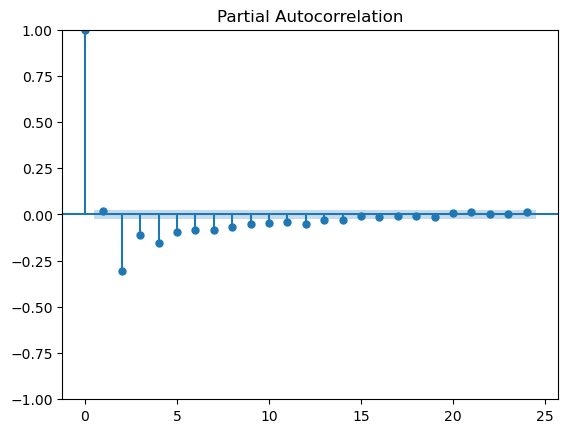

In [263]:
#pacf plot
plt.figure()
plot_pacf(y, lags = 24)
plt.show()

In [264]:
train_size = int(len(weather) * 0.5)
train = weather[:train_size]
test = weather[train_size:]

X_train = train.drop(columns=['temp (F)'])
y_train = train['temp (F)']
X_test = test.drop(columns=['temp (F)'])
y_test = test['temp (F)']

In [265]:
model = ARIMA(y_train, exog = X_train, order = (3, 1, 1))
results = model.fit()

In [266]:
y_pred = results.forecast(steps = len(y_test), exog = X_test)

#R-squared
r2 = r2_score(y_test, y_pred)
print(f"R^2 Score: {r2}")

#root mean square error (measure of accuracy)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'RMSE: {rmse:.2f}')

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae}")

R^2 Score: 0.9991201234016468
RMSE: 0.49
MAE: 0.3948199208955483


### Rainfall

In [267]:
#adf test
result = adfuller(weather['rain_3h (in)'],
                 maxlag = None,
                 regression = 'ct',
                 autolag = 'AIC',
                 store = False,
                 regresults = True)


print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
# current p-value is lower than 0.05 so data is stationary (means differencing is NOT needed)

ADF Statistic: -23.965138267141295
p-value: 0.0


<Figure size 640x480 with 0 Axes>

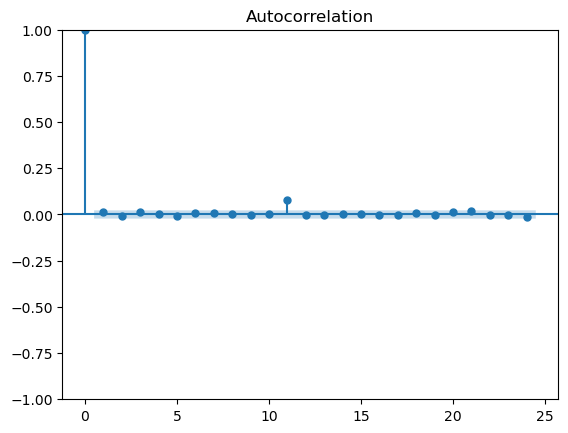

In [268]:
y = weather['rain_3h (in)']

#acf plot for temp
plt.figure()
plot_acf(y, lags = 24)
plt.show()

<Figure size 640x480 with 0 Axes>

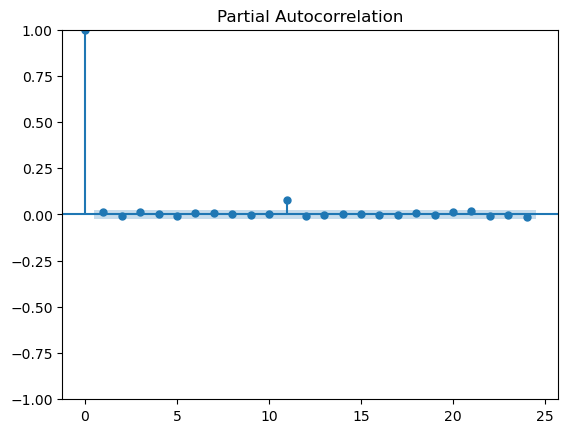

In [269]:
#pacf plot
plt.figure()
plot_pacf(y, lags = 24)
plt.show()

In [270]:
#test and train split
train_size = int(len(weather) * 0.5)
train = weather[:train_size]
test = weather[train_size:]

X_train = train.drop(columns=['rain_3h (in)'])
y_train = train['rain_3h (in)']
X_test = test.drop(columns=['rain_3h (in)'])
y_test = test['rain_3h (in)']

# ARIMAX model
model = ARIMA(y_train, exog = X_train, order = (1, 0, 1))
results = model.fit()

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [271]:
y_pred = results.forecast(steps = len(y_test), exog = X_test)

#R-squared
r2 = r2_score(y_test, y_pred)
print(f"R^2 Score: {r2}")

#root mean square error (measure of accuracy)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'RMSE: {rmse:.2f}')

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae}")

R^2 Score: 0.0775140633346817
RMSE: 0.12
MAE: 0.03258787006587397


# Random Forest

In [272]:
# additional packages
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

### Temperature

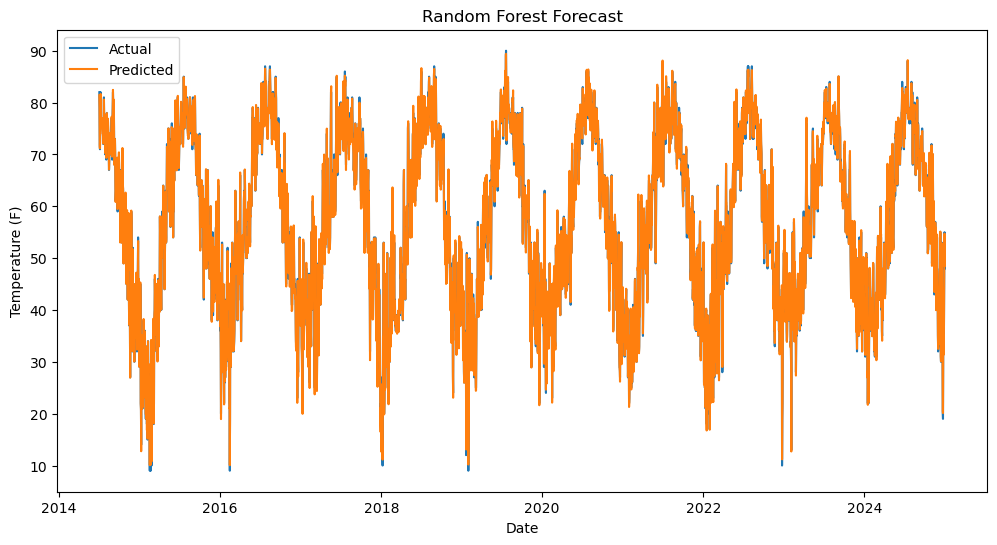

RMSE: 0.55
R-squared: 0.9989
MAE: 0.41922575599582906


In [273]:
# creating Random Forest lag features
def create_lag_features(df, target_col, lags = 2):
    for lag in range(1, lags + 1):
        df[f'{target_col}_lag{lag}'] = df[target_col].shift(lag)
    df = df.dropna()
    return weather

df = create_lag_features(weather, 'temp (F)', lags = 2)

#split into test and train
train_size = int(len(df) * 0.5)
train = df[:train_size]
test = df[train_size:]

X_train = train.drop(columns=['temp (F)'])
y_train = train['temp (F)']
X_test = test.drop(columns=['temp (F)'])
y_test = test['temp (F)']

# random forest for time series
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

# Plot predictions vs actual
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, y_pred, label='Predicted')
plt.xlabel('Date')
plt.ylabel('Temperature (F)')
plt.title('Random Forest Forecast')
plt.legend()
plt.show()

#accuracy tests
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'RMSE: {rmse:.2f}')

# R-squared
score = r2_score(y_test, y_pred)
print(f"R-squared: {score:.4f}")

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae}")

### Rainfall

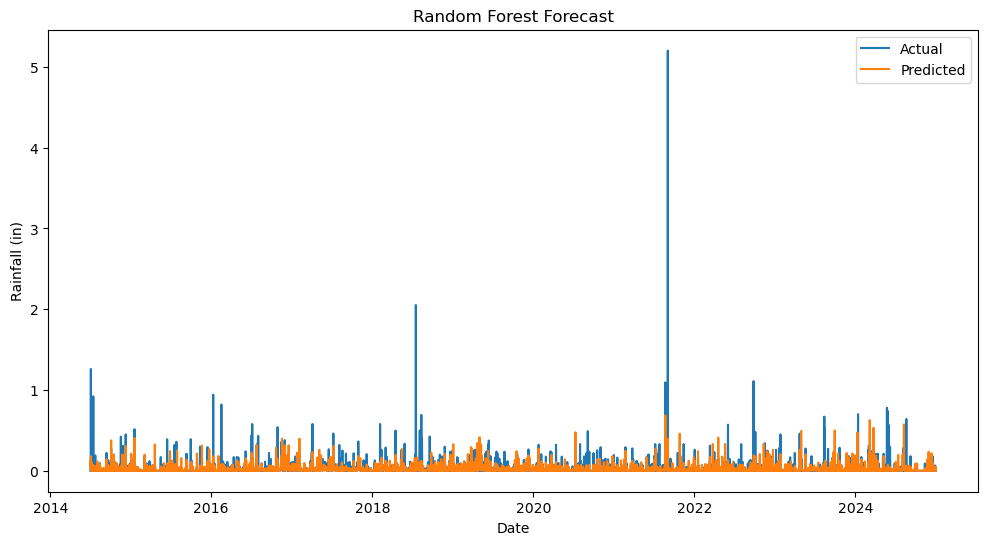

RMSE: 0.11
R-squared: 0.1537
MAE: 0.026358127878860035


In [237]:
# creating Random Forest lag features
def create_lag_features(df, target_col, lags = 2):
    for lag in range(1, lags + 1):
        df[f'{target_col}_lag{lag}'] = df[target_col].shift(lag)
    df = df.dropna()
    return weather

df = create_lag_features(weather, 'rain_3h (in)', lags = 2)

#test and train split
train_size = int(len(df) * 0.5)
train = df[:train_size]
test = df[train_size:]

X_train = train.drop(columns=['rain_3h (in)'])
y_train = train['rain_3h (in)']
X_test = test.drop(columns=['rain_3h (in)'])
y_test = test['rain_3h (in)']

# random forest for time series
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

# Plot predictions vs actual
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, y_pred, label='Predicted')
plt.xlabel('Date')
plt.ylabel('Rainfall (in)')
plt.title('Random Forest Forecast')
plt.legend()
plt.show()

#accuracy tests
#root mean square error (measure of accuracy)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'RMSE: {rmse:.2f}')

# R-squared
score = r2_score(y_test, y_pred)
print(f"R-squared: {score:.4f}")

#MAE
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae}")